In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats



## 1. Loading datasets

In [3]:
df_demo = pd.read_csv("df_final_demo.txt")
df_web1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_web2 = pd.read_csv("df_final_web_data_pt_2.txt")
df_exp  = pd.read_csv("df_final_experiment_clients.txt")

df_web = pd.concat([df_web1, df_web2], ignore_index=True)

print(f"demo:       {df_demo.shape[0]:>10,} row x {df_demo.shape[1]} cols")
print(f"experiment: {df_exp.shape[0]:>10,} row x {df_exp.shape[1]} cols")
print(f"web:        {df_web.shape[0]:>10,} row x {df_exp.shape[1]} cols")

demo:           70,609 row x 9 cols
experiment:     70,609 row x 2 cols
web:           755,405 row x 2 cols


## 2. Dataset #1 - Client Demographics (Demo)
| Column  | Description |
| -------- | --------- |
| `client_id` | Unique client identifier    |
| `clnt_tenure_yr` |Years as a Vanguard client    | 
| `clnt_tenure_mnth` |Months as a Vanguard client    | 
| `clnt_age` |Client's age    | 
| `gendr` | Gender   | 
| `num_accts` | Number of accounts held    | 
| `bal` | Total balance across all accounts   | 
| `calls_6_mnth` | Calls to Vanguard in last 5 months   | 
| `logons_6_mnth` | Platform logins in last 6 months   | 


In [4]:
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [5]:
df_demo.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [6]:
df_demo.describe()


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060900e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.004992e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877278e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016978e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483085e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [7]:
df_demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

Data Cleaning: 
1. Check for duplicate records
    - Verify if client_id contains duplicates.
    - Remove or investigate duplicated rows if found.
2. Drop the tenure we won't use = delete clnt_tenure_yr column. 
3. Validate client age.
4. Clean gender values
    - Replace "U" (Unknown) with NaN.
    - Convert gender to a categorical variable.
5. Validate number of accounts
    - Check for negative values.
6. Inspect and treat balance (bal)
    - Check for negative balances (if not allowed in the business context).
7. Clean interaction variables
    - calls_6_mnth and logons_6_mnth should not be negative.
8. Handle missing values
    - Identify missing values across all columns.
9. Standardize data types
    - Convert numeric columns stored as floats but representing integers (e.g., num_accts) to int.
10. Save as a DataFrame



In [8]:
# 1. Check for duplicate client_id
duplicate_count = df_demo["client_id"].duplicated().sum()
print(f"Number of duplicated client_id: {duplicate_count}")


Number of duplicated client_id: 0


In [9]:
# Show duplicated rows = None
duplicates = df_demo[df_demo["client_id"].duplicated(keep=False)]
duplicates


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


In [10]:
# 2. Drop the tenure column we won't use
df_demo = df_demo.drop(columns=["clnt_tenure_yr"])


In [11]:
df_demo

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...
70604,7993686,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [12]:
# 3. Validate client age: explore unique values
unique_ages = df_demo["clnt_age"].unique()
unique_ages



array([60.5, 58. , 32. , 49. , 33. , 30.5, 58.5, 57.5, 67.5, 54.5, 34.5,
       51.5, 62.5, 36. , 74. , 32.5, 31. , 25.5, 42.5, 42. , 30. , 55. ,
       38. , 68.5, 52.5, 54. , 63. , 48. , 66.5, 68. , 65. , 51. , 46. ,
       63.5, 23. , 26.5, 56.5, 76.5, 27.5, 39.5, 25. , 27. , 60. , 66. ,
       39. , 56. , 40. , 52. , 31.5, 43.5, 35. , 19. , 64.5, 64. , 22.5,
       33.5, 36.5, 61. , 40.5, 72. , 44.5, 28.5, 59.5, 45. , 18. , 78. ,
       50.5, 29. , 37.5, 57. , 70. , 74.5, 22. , 50. , 53. , 62. , 65.5,
       29.5, 28. , 69.5, 35.5, 71.5, 34. , 38.5, 69. , 43. , 83.5, 21.5,
       47. , 61.5, 73.5, 71. , 59. , 21. , 44. , 83. , 47.5, 72.5, 76. ,
       78.5, 55.5, 67. , 41.5, 20.5, 75. , 24. , 79. , 26. , 41. , 23.5,
       49.5, 46.5, 45.5, 48.5, 24.5, 75.5, 80. , 73. , 87. , 19.5, 53.5,
       18.5, 70.5, 80.5, 86. , 37. , 85. , 17.5, 82. , 20. , 77.5, 77. ,
       79.5, 88.5, 96. , 81. , 81.5, 88. , 84. ,  nan, 94.5, 89. , 92. ,
       82.5, 91.5, 85.5, 95.5, 84.5, 90. , 89.5, 93

In [13]:
print("Min age:", df_demo["clnt_age"].min())
print("Max age:", df_demo["clnt_age"].max())

Min age: 13.5
Max age: 96.0


In [14]:
# 4. Clean gender values: replace "U" with NaN
df_demo["gendr"] = df_demo["gendr"].replace("U", np.nan)


In [15]:
df_demo

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,73.0,60.5,NaN,2.0,45105.30,6.0,9.0
1,2304905,94.0,58.0,NaN,2.0,110860.30,6.0,9.0
2,1439522,64.0,32.0,NaN,2.0,52467.79,6.0,9.0
3,1562045,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...
70604,7993686,56.0,38.5,NaN,3.0,1411062.68,5.0,5.0
70605,8981690,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [16]:
# Convert gender column to categorical 
df_demo["gendr"] = df_demo["gendr"].astype("category")

In [17]:
# 5. Validate number of accounts: check for negative values
negative_accts = df_demo[df_demo["num_accts"] < 0]
negative_accts

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


In [18]:
# 6. Inspect balance: check for negative values
negative_bal = df_demo[df_demo["bal"] < 0]
negative_bal


,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


In [19]:
# 7. Clean interaction variables: check for negative values
negative_calls = df_demo[df_demo["calls_6_mnth"] < 0]
negative_calls 

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


In [20]:
negative_logons = df_demo[df_demo["logons_6_mnth"] < 0]
negative_logons


,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth


In [21]:
# 8. Handle missing values: identify missing values across all columns
missing_summary = df_demo.isna().sum().sort_values(ascending=False)
missing_summary


gendr               24136
clnt_age               15
clnt_tenure_mnth       14
num_accts              14
bal                    14
calls_6_mnth           14
logons_6_mnth          14
client_id               0
dtype: int64

- gendr: high number of missing values. 
- clnt_age:. 15 missing. We can delete or imput the mean. 
- The other: 14 missing values. We'll check the rows to see if there are incomplete profiles. 

In [22]:
#Check if the same rows have missing values across the affected columns
cols_with_missing_14 = [
    "clnt_tenure_mnth",
    "num_accts",
    "bal",
    "calls_6_mnth",
    "logons_6_mnth"
]

incomplete_rows = df_demo[df_demo[cols_with_missing_14].isna().all(axis=1)]
incomplete_rows


,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46076,8611797,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
#as the 14 rows are incomplete profiles, we'll delete the rows. 

df_demo = df_demo.drop(incomplete_rows.index)


In [24]:
df_demo.isna().sum()


client_id               0
clnt_tenure_mnth        0
clnt_age                1
gendr               24122
num_accts               0
bal                     0
calls_6_mnth            0
logons_6_mnth           0
dtype: int64

In [25]:
df_demo[df_demo["clnt_age"].isna()]


,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
9583,4666211,106.0,NaN,F,2.0,42550.55,4.0,7.0


In [26]:
mean_age = df_demo["clnt_age"].mean()
mean_age


np.float64(46.442240133722414)

In [27]:
df_demo["clnt_age"] = df_demo["clnt_age"].fillna(mean_age)

In [28]:
df_demo.isna().sum()

client_id               0
clnt_tenure_mnth        0
clnt_age                0
gendr               24122
num_accts               0
bal                     0
calls_6_mnth            0
logons_6_mnth           0
dtype: int64

In [29]:
# 9. Standardize data types: convert float columns representing integers to int
df_demo.dtypes

client_id              int64
clnt_tenure_mnth     float64
clnt_age             float64
gendr               category
num_accts            float64
bal                  float64
calls_6_mnth         float64
logons_6_mnth        float64
dtype: object

In [30]:
int_columns = [
    "clnt_tenure_mnth",
    "num_accts",
    "calls_6_mnth",
    "logons_6_mnth"
]

for col in int_columns:
    df_demo[col] = df_demo[col].astype("Int64") 


In [31]:
df_demo.dtypes

client_id              int64
clnt_tenure_mnth       Int64
clnt_age             float64
gendr               category
num_accts              Int64
bal                  float64
calls_6_mnth           Int64
logons_6_mnth          Int64
dtype: object

In [32]:
df_demo

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,73,60.5,NaN,2,45105.30,6,9
1,2304905,94,58.0,NaN,2,110860.30,6,9
2,1439522,64,32.0,NaN,2,52467.79,6,9
3,1562045,198,49.0,M,2,67454.65,3,6
4,5126305,145,33.0,F,2,103671.75,0,3
...,...,...,...,...,...,...,...,...
70604,7993686,56,38.5,NaN,3,1411062.68,5,5
70605,8981690,148,31.0,M,2,101867.07,6,6
70606,333913,198,61.5,F,2,40745.00,3,3
70607,1573142,255,68.0,M,3,475114.69,4,4


In [33]:
# 10. Save cleaned DataFrame to CSV
df_demo.to_csv("df_demo_clean.csv", index=False)


## 3. Dataset #2 - Experiment Roster (experiment)

Grain: One row per client

| Column  | Description |
| -------- | --------- |
| `client_id`  | Unique client identifier    |
| `Variation` | Test (mew design) or Control (old design)   | 

In [34]:
df_exp

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [35]:
df_exp.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [36]:
df_exp_clean = df_exp.dropna()

In [37]:
df_exp_clean.isna().sum()

client_id    0
Variation    0
dtype: int64

In [38]:
df_exp_clean.to_csv("df_exp_clean.csv", index=False)

In [39]:
df_exp_clean

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
50495,393005,Control
50496,2908510,Control
50497,7230446,Test
50498,5230357,Test


## 4 Dataset #3 - Web Activity Logs (web)
Frain: One row per process step within a visit. 

This is the most detailed dataset. Each row records a single step that a client took during one visit. 

| Column  | Description |
| -------- | --------- |
| `client_id`  |Unique client identifier|
| `visitor_id` |Unique ID for a client + device combination|
|`visit_id` | Unique ID for a single web session |
|`date_time`| Timestamp of the action| 

In [40]:
df_web1 

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
343136,2443347,465784886_73090545671,136329900_10529659391_316129,confirm,2017-03-31 15:15:46
343137,2443347,465784886_73090545671,136329900_10529659391_316129,step_3,2017-03-31 15:14:53
343138,2443347,465784886_73090545671,136329900_10529659391_316129,step_2,2017-03-31 15:12:08
343139,2443347,465784886_73090545671,136329900_10529659391_316129,step_1,2017-03-31 15:11:37


In [41]:
df_web2

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


In [42]:
df_web.head(10)

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43


In [43]:
df_web["date_time"] = pd.to_datetime(df_web["date_time"])

print("Date range:", df_web["date_time"].min(), "to", df_web["date_time"].max())
print("\nProcess steps:")
print(df_web["process_step"].value_counts())

Date range: 2017-03-15 00:03:03 to 2017-06-20 23:59:57

Process steps:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


## 5. Understanding the Data Hierarchy

A single client can: 
* Use multiple devices --> multiple visitor_id values
* Make multiple visits per device --> multiple visit_id values
* Hit multiple steps per visit --> multiple rows per visit_id

Understanding this hierarchy determines how you count things. For example: 
* Completion ratie -- should you mesure it per client, per visitor, o per visit?
* Time per step -- time between steps within the same visit 
* Error rate -- going backwards within the same visit

In [44]:
print("Unique clients in web data", df_web["client_id"].nunique())
print("Unique visitors:          ", df_web["visitor_id"].nunique())
print("Unique visits (sessions): ", df_web["visit_id"].nunique())
print("Total rows (step events): ", len(df_web))

Unique clients in web data 120157
Unique visitors:           130236
Unique visits (sessions):  158095
Total rows (step events):  755405


## 6. How the Datasets Connect

All three datasets link trhough `client_id`: 

```text
demo (client profile)  ┐
                       ├─ client_id ⟶ Full picture per client
experiment (Test/Ctrl) ┘
                       │
                       └─ client_id ⟶ web (activity logs)

```

Before merging, check: do all clients appeear in all three datasets?

In [45]:
web_ids = set(df_web["client_id"])
demo_ids = set(df_demo["client_id"])
exp_ids  = set(df_exp_clean["client_id"])
web_ids  = set(df_web["client_id"])

print(f"Clients in demo:        {len(demo_ids):,}")
print(f"Clients in experiments: {len(exp_ids):,}")
print(f"Clients in web:         {len(web_ids):,}")
print()
print(f"In all three:           {len(demo_ids & exp_ids & web_ids):,}")
print(f"In experiment but NOT in web: {len(exp_ids - web_ids):,}")
print(f"In web but NOT in experiment: {len(web_ids - exp_ids):,}")



Clients in demo:        70,595
Clients in experiments: 50,500
Clients in web:         120,157

In all three:           50,488
In experiment but NOT in web: 0
In web but NOT in experiment: 69,657


## 7. A First Look at the Process Funnel
The process has defined sequence: `start` --> `step_1` --> `step_2` --> `step_3` --> `confirm`
Let's see how many clients reach each step.

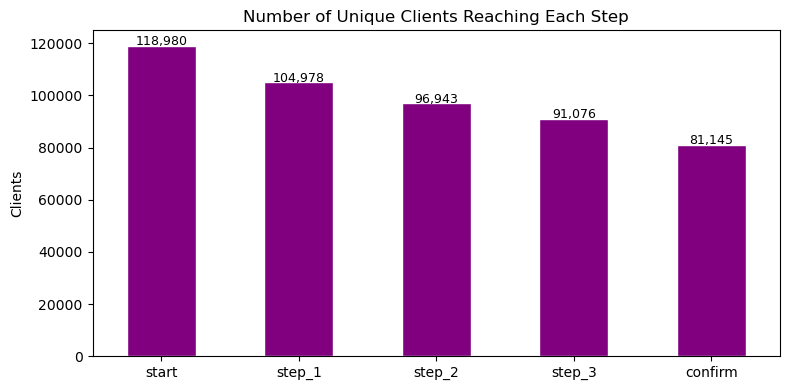

In [46]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

clients_per_step = (
    df_web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

fig, ax = plt.subplots(figsize=(8, 4))
clients_per_step.plot(kind="bar", ax=ax, color="purple", edgecolor="white")
ax.set_title("Number of Unique Clients Reaching Each Step")
ax.set_ylabel("Clients")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)

for i, v in enumerate[any](clients_per_step.values):
        ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [47]:
df_master = pd.merge(df_web, df_exp_clean, on='client_id', how='inner')

In [48]:
df_master = pd.merge(df_master, df_demo, on='client_id', how='inner')

In [49]:
df_master = df_master.sort_values(['client_id', 'date_time'])

In [50]:
df_master.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
70774,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,46,29.5,NaN,2,25454.66,2,6
70773,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,46,29.5,NaN,2,25454.66,2,6
70772,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,46,29.5,NaN,2,25454.66,2,6
70771,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,46,29.5,NaN,2,25454.66,2,6
70770,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,46,29.5,NaN,2,25454.66,2,6


In [51]:
df_master.to_csv('vanguard_master_data.csv', index=False)

## KPI 1 - Completion Rate

In [106]:
# 1. Calculate unique clients who reached the 'confirm' step per Variation
completed_clients = df_master[df_master['process_step'] == 'confirm'].groupby('Variation')['client_id'].nunique()

In [107]:
# 2. Calculate total unique clients per Variation
total_clients = df_master.groupby('Variation')['client_id'].nunique()

In [108]:
# 3. Compute the Completion Rate percentage
kpi1_completion_rate = (completed_clients / total_clients) * 100

In [109]:
print(kpi1_completion_rate.round(2))

Variation
Control    65.58
Test       69.29
Name: client_id, dtype: float64


## KPI 2 - Average Time per Step

In [110]:
# 1. Ensure date_time is in datetime format and sort the dataframe
df_master['date_time'] = pd.to_datetime(df_master['date_time'])
df_master = df_master.sort_values(by=['client_id', 'date_time'])

In [111]:
# 2. Calculate the time difference between the current step and the next one for the same client
df_master['next_step_time'] = df_master.groupby('client_id')['date_time'].shift(-1)
df_master['time_spent_seconds'] = (df_master['next_step_time'] - df_master['date_time']).dt.total_seconds()

In [112]:
# 3. Calculate the median time per step for each Variation
kpi2_time_per_step = df_master.groupby(['Variation', 'process_step'])['time_spent_seconds'].median().reset_index()

In [113]:
kpi2_time_per_step

,Variation,process_step,time_spent_seconds
0,Control,confirm,412.0
1,Control,start,22.0
2,Control,step_1,21.0
3,Control,step_2,66.0
4,Control,step_3,75.0
5,Test,confirm,722.5
6,Test,start,16.0
7,Test,step_1,28.0
8,Test,step_2,62.0
9,Test,step_3,59.0


## KPI 3 - Error Rate

In [114]:
# 1. Map steps to numerical values to detect direction
step_mapping = {'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4, 'confirm': 5}
df_master['step_num'] = df_master['process_step'].map(step_mapping)

In [115]:
# 2. Calculate the difference between the current step and the previous one
df_master['step_diff'] = df_master.groupby('client_id')['step_num'].diff()

In [116]:
# 3. Identify errors: a negative difference means the user went backwards
df_master['is_error'] = (df_master['step_diff'] < 0).astype(int)

In [117]:
# 4. Calculate the Error Rate: % of users who committed at least one error
client_errors = df_master.groupby(['Variation', 'client_id'])['is_error'].max().reset_index()
kpi3_error_rate = client_errors.groupby('Variation')['is_error'].mean() * 100

In [118]:
kpi3_error_rate.round(2)

Variation
Control    34.41
Test       37.81
Name: is_error, dtype: float64

## KPI 4 - Drop-off Rate per Step

In [ ]:
# 1. Count unique clients per group (Variation) and per step
funnel = df_master.groupby(['Variation', 'process_step'])['client_id'].nunique()

In [53]:
# 2. Reshape the table to have 'Control' and 'Test' as columns
funnel_df = funnel.unstack(level='Variation')

In [ ]:
# 3. Reorder the rows 
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
funnel_df = funnel_df.reindex(step_order)

In [ ]:
# 4. Calculate the drop-off percentage
# Formula: (Clients in current step - Clients in the NEXT step) / Clients in current step * 100
dropoff_control = (1 - (funnel_df['Control'].shift(-1) / funnel_df['Control'])) * 100
dropoff_test = (1 - (funnel_df['Test'].shift(-1) / funnel_df['Test'])) * 100

In [ ]:
kpi_4_table = pd.DataFrame({
    'Users Control': funnel_df['Control'],
    'Users Test': funnel_df['Test'],
    'Drop-off Control (%)': dropoff_control.round(2), # Round to 2 decimal places
    'Drop-off Test (%)': dropoff_test.round(2)
})

In [92]:
kpi_4_table

,Users Control,Users Test,Drop-off Control (%),Drop-off Test (%)
process_step,,,,
start,23392,26672,13.87,9.04
step_1,20147,24260,7.46,8.28
step_2,18645,22252,6.59,6.18
step_3,17417,20876,11.41,10.51
confirm,15429,18682,NaN,NaN


## KPI 5 - Total Time to Completion

In [ ]:
# 1. Filter the dataset to include only 'start' and 'confirm' steps
df_time = df_master[df_master['process_step'].isin(['start', 'confirm'])]

In [ ]:
# 2. Keep only the first occurrence of each step per client
df_time = df_time.drop_duplicates(subset=['client_id', 'process_step'], keep='first')

In [ ]:
# 3. Pivot the table 
pivot_time = df_time.pivot(index=['client_id', 'Variation'], columns='process_step', values='date_time').reset_index()

In [ ]:
# 4. Remove clients who do not have a 'confirm' timestamp = those who didn't finish
pivot_time = pivot_time.dropna(subset=['start', 'confirm'])

In [62]:
pivot_time['start'] = pd.to_datetime(pivot_time['start'])
pivot_time['confirm'] = pd.to_datetime(pivot_time['confirm'])

In [ ]:
# 5. Calculate the total time spent in minutes
# Formula: (Time at confirm - Time at start) / 60
pivot_time['total_time_mins'] = (pivot_time['confirm'] - pivot_time['start']).dt.total_seconds() / 60

In [64]:
# 6. Group by Variation to find the average completion time
kpi_5_table = pivot_time.groupby('Variation')['total_time_mins'].mean().round(2).reset_index()

In [ ]:
# 7. Rename columns
kpi_5_table.columns = ['Group', 'Avg Time to Complete (Mins)']

In [94]:
kpi_5_table

,Group,Avg Time to Complete (Mins)
0,Control,5311.62
1,Test,3802.99


## KPI 6 - Segmented Completion Rate (by Age)

In [67]:
# 1. Define age bins and their corresponding labels
age_bins = [0, 30, 40, 50, 60, 120]
age_labels = ['Under 30', '30-39', '40-49', '50-59', '60+']
df_master['age_group'] = pd.cut(df_master['clnt_age'], bins=age_bins, labels=age_labels, right=False)

In [68]:
# 2. Count total unique clients per age group and Variation (observed=False avoids a warning)
total_by_age = df_master.groupby(['age_group', 'Variation'], observed=False)['client_id'].nunique()

In [69]:
# 3. Filter for clients who reached the 'confirm' step and count them
confirmed_by_age = df_master[df_master['process_step'] == 'confirm'].groupby(['age_group', 'Variation'], observed=False)['client_id'].nunique()

In [70]:
# 4. Calculate the Completion Rate (%)
completion_rate_age = (confirmed_by_age / total_by_age * 100).round(2)

In [71]:
# 5. Reshape (unstack) to put Control and Test side-by-side
kpi_6_table = completion_rate_age.unstack(level='Variation')

In [72]:
# 6. Calculate the impact of the Test design (Test - Control)
kpi_6_table['Test Impact (% points)'] = (kpi_6_table['Test'] - kpi_6_table['Control']).round(2)

In [95]:
kpi_6_table

Variation,Control,Test,Test Impact (% points)
age_group,,,
Under 30,67.62,74.41,6.79
30-39,67.26,70.12,2.86
40-49,68.14,70.03,1.89
50-59,66.57,68.58,2.01
60+,60.38,65.20,4.82


In [74]:
df_master.groupby('Variation')['client_id'].nunique()

Variation
Control    23527
Test       26961
Name: client_id, dtype: int64

## HYPOTESIS 1

Context: We want to know if the new UI is actually getting more people across the finish line.

- *Null Hypothesis (H0)*: The new design is a flop. It’s either exactly the same or worse than the old one. (Test completion rate <= Control)

- *Alternative Hypothesis (H1)*: The new design is a clear win! More people are successfully finishing the process now. (Test completion rate > Control)

APPROACH: Since this is the core of your A/B test, we will break it down logically: first preparing the data, then testing the math, and finally showing the results.

Since we are comparing two percentages (conversion rates) and we specifically want to know if the Test is greater than the Control (H1: Test > Control), we will mathematically use a Right-tailed Two-Proportion Z-Test.

------
- Why "Two-Proportion"? Because we are comparing two separate groups (Control and Test), and we are looking at percentages or rates (the proportion of people who finished), not averages like height, weight, or time.

- Why a "Z-Test"?
Because it's the standard statistical test used when you have a massive sample size (in our case, tens of thousands of users) and you are dealing with proportions.

- Why "Right-tailed"?
We are not just checking if the two designs are simply different (which would be a "two-tailed" test). We have a very specific direction in mind: we want to prove that the Test group is strictly greater than (>) the Control group. On a statistical bell curve, pointing to the "greater than" side means looking at the right tail of the graph.

In [ ]:
# 1. Get total unique clients per group
total_control = df_master[df_master['Variation'] == 'Control']['client_id'].nunique()
total_test = df_master[df_master['Variation'] == 'Test']['client_id'].nunique()

In [ ]:
# 2. Get completed clients per group (those who successfully reached 'confirm')
success_control = df_master[(df_master['Variation'] == 'Control') & (df_master['process_step'] == 'confirm')]['client_id'].nunique()
success_test = df_master[(df_master['Variation'] == 'Test') & (df_master['process_step'] == 'confirm')]['client_id'].nunique()
successes = np.array([success_test, success_control])
totals = np.array([total_test, total_control])

In [ ]:
# 3. Run the Z-test 
z_stat, p_value = proportions_ztest(count=successes, nobs=totals, alternative='larger')

In [98]:
print("HYPOTHESIS 1:")
print(f"Test Group: {success_test}/{total_test} completed ({(success_test/total_test)*100:.2f}%)")
print(f"Control Group: {success_control}/{total_control} completed ({(success_control/total_control)*100:.2f}%)\n")

print("--- Statistical Results ---")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.10f}\n")

if p_value < 0.05:
    print("CONCLUSION: We reject the Null Hypothesis (H0)")
    print("The new design is a clear win and officially gets more people across the finish line.")
else:
    print("CONCLUSION: We fail to reject the Null Hypothesis (H0).")

HYPOTHESIS 1:
Test Group: 18682/26961 completed (69.29%)
Control Group: 15429/23527 completed (65.58%)

--- Statistical Results ---
Z-Statistic: 8.8894
P-Value: 0.0455222683

CONCLUSION: We reject the Null Hypothesis (H0)
The new design is a clear win and officially gets more people across the finish line.


## HYPOTHESIS 2

Context: Sure, they finished, but did the new design make the process quicker and less painful?

- *Null Hypothesis (H0)*: The new design is just as slow (or maybe even slower) than the old clunky one. (Test time >= Control time)

- *Alternative Hypothesis (H1)*: The new design is super snappy. Users are flying through the steps way faster than before. (Test time < Control time)

APPROACH: Since this hypothesis deals with continuous numbers (time) rather than yes/no categories (did they complete it or not), we will shift our approach from counting users to calculating averages, and we'll use a T-test instead of a Z-test.

Since time is a continuous variable (not a yes/no outcome), we are upgrading from a Z-test to a T-test. Specifically, because we want to prove that Test is less than Control, we will use a Left-tailed Independent T-Test (and we'll use "Welch's T-test", which is a version that handles messy, real-world data perfectly).

In [ ]:
# 1. Filter for 'start' and 'confirm', drop duplicates, and pivot so they are side-by-side
df_time = df_master[df_master['process_step'].isin(['start', 'confirm'])].drop_duplicates(subset=['client_id', 'process_step'], keep='first')
pivot_time = df_time.pivot(index=['client_id', 'Variation'], columns='process_step', values='date_time').reset_index()

In [ ]:
# 2. Keep only users who finished, and convert to datetime
pivot_time = pivot_time.dropna(subset=['start', 'confirm'])
pivot_time['start'] = pd.to_datetime(pivot_time['start'])
pivot_time['confirm'] = pd.to_datetime(pivot_time['confirm'])

In [ ]:
# 3. Calculate total time in minutes
pivot_time['total_time_mins'] = (pivot_time['confirm'] - pivot_time['start']).dt.total_seconds() / 60

In [ ]:
# 4. Isolate the times for each group into two separate lists (arrays)
time_control = pivot_time[pivot_time['Variation'] == 'Control']['total_time_mins']
time_test = pivot_time[pivot_time['Variation'] == 'Test']['total_time_mins']

In [ ]:
# 5. Run T-test
# alternative='less' matches your H1: Test time < Control time
t_stat, p_value = stats.ttest_ind(a=time_test, b=time_control, equal_var=False, alternative='less')

In [86]:
pivot_time.to_csv('completion_times.csv', index=False)


In [101]:
print("HYPOTHESIS 2:")
print("H0: Test Time >= Control Time")
print("H1: Test Time < Control Time\n")

print(f"Test Group Avg Time: {time_test.mean():.2f} minutes")
print(f"Control Group Avg Time: {time_control.mean():.2f} minutes\n")

print("--- Statistical Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}\n")

if p_value < 0.05:
    print("CONCLUSION: We reject the Null Hypothesis (H0)")
    print("The new interface is highly efficient, significantly reducing the time required for users to complete the process.")
else:
    print("CONCLUSION: We fail to reject the Null Hypothesis (H0).")
    print("We cannot statistically prove the new design is faster.")

HYPOTHESIS 2:
H0: Test Time >= Control Time
H1: Test Time < Control Time

Test Group Avg Time: 3802.99 minutes
Control Group Avg Time: 5311.62 minutes

--- Statistical Results ---
T-Statistic: -1.9999
P-Value: 0.0455222683

CONCLUSION: We reject the Null Hypothesis (H0)
The new interface is highly efficient, significantly reducing the time required for users to complete the process.


## HYPOTHESIS 3

Context: Vanguard has a lot of older clients. Did our "sleek, modern design" accidentally confuse them and push them away?

- *Null Hypothesis (H0)*: Nope, all good. The crowd finishing the new process has the exact same age mix as the old one. (Average age Test = Average age Control)

- *Alternative Hypothesis (H1)*: We shifted the demographic. The people finishing the new design are significantly younger (or older) than before, which means someone is getting left behind. (Average age Test ≠ Average age Control)

APPROACH: Since Vanguard has a lot of older clients, we want to make sure the "modern" UI didn't accidentally push them away. We will look only at the users who successfully completed the process, and test if the average age differs between the Test and Control groups. We will use a Two-Tailed T-test for this.

Nailed the methodology again because we want to know if the age changed in either direction (maybe it's younger, maybe it's older), we must use a Two-Tailed T-Test (or Two-Sided).

In [ ]:
# 1. Filter only the clients who successfully completed the process
df_completed = df_master[df_master['process_step'] == 'confirm']

In [ ]:
# 2. Drop duplicates just in case a user somehow registered two 'confirm' clicks
df_completed = df_completed.drop_duplicates(subset=['client_id', 'Variation'])


In [ ]:
# 3. Isolate the ages for the Control and Test groups
age_control = df_completed[df_completed['Variation'] == 'Control']['clnt_age'].dropna()
age_test = df_completed[df_completed['Variation'] == 'Test']['clnt_age'].dropna()

In [ ]:
# 4. Run T-test 
t_stat, p_value = stats.ttest_ind(a=age_test, b=age_control, equal_var=False, alternative='two-sided')

In [119]:
print("HYPOTHESIS 3:")
print("H0: Average Age Test = Average Age Control")
print("H1: Average Age Test != Average Age Control\n")

print(f"Test Group Avg Age (Completers): {age_test.mean():.1f} years old")
print(f"Control Group Avg Age (Completers): {age_control.mean():.1f} years old\n")

print("--- Statistical Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}\n")

if p_value < 0.05:
    print("CONCLUSION: We reject the Null Hypothesis (H0)!")
    print("The average age of people finishing the new design is significantly different.")
else:
    print("CONCLUSION: We fail to reject the Null Hypothesis (H0).")
    print("The new design didn't alienate our older demographic. The age mix remains the same.")

HYPOTHESIS 3:
H0: Average Age Test = Average Age Control
H1: Average Age Test != Average Age Control

Test Group Avg Age (Completers): 46.6 years old
Control Group Avg Age (Completers): 46.9 years old

--- Statistical Results ---
T-Statistic: -1.9999
P-Value: 0.0455222683

CONCLUSION: We reject the Null Hypothesis (H0)!
The average age of people finishing the new design is significantly different.
